# Image Classification with CNN — CIFAR-10

## 1. CIFAR-10 Dataset

The CIFAR-10 dataset, created by Alex Krizhevsky, Vinod Nair, and Geoffrey Hinton, consists of 60,000 color images of size 32×32 pixels across 10 classes:

- Airplane  
- Automobile  
- Bird  
- Cat  
- Deer  
- Dog  
- Frog  
- Horse  
- Ship  
- Truck  

The dataset is split into 50,000 training images and 10,000 test images. It is balanced, with each class containing 6,000 images.

---

## 2. Initial Convolutional Neural Network (CNN) Model

This baseline model serves as the starting point for experimentation. Subsequent sections introduce architectural and training adjustments to improve performance.

---

### 2.1 Model Architecture

* Input: 3×32×32 (RGB images)
* Convolutional Layers:
  * Layer 1: 32 filters, kernel size 3×3, stride 1, padding 1, ReLU activation  
  * Layer 2: 64 filters, kernel size 3×3, stride 1, padding 1, ReLU activation  
* Pooling Layers:  
  * Max pooling (2×2) to reduce spatial dimensions and retain important features  
* Fully Connected Layers:
  * Dense Layer: Flattened feature maps (4096 units) → 128 neurons, ReLU activation  
  * Output Layer: 10 neurons with Softmax activation, producing class probabilities  

---

### 2.2 Hyperparameters

- Learning rate: 0.001  
- Batch size: 32  
- Epochs: 5  

---

### 2.3 Optimization Techniques

- Data augmentation: random horizontal flipping, random cropping, and normalization  
- Optimizer: Adam, which adapts learning rates for each parameter during training  

---

### 2.4 Evaluation

- Loss function: categorical cross-entropy  
- Accuracy:  
  - Training accuracy: 65.52%  
  - Validation accuracy: 66.39%  

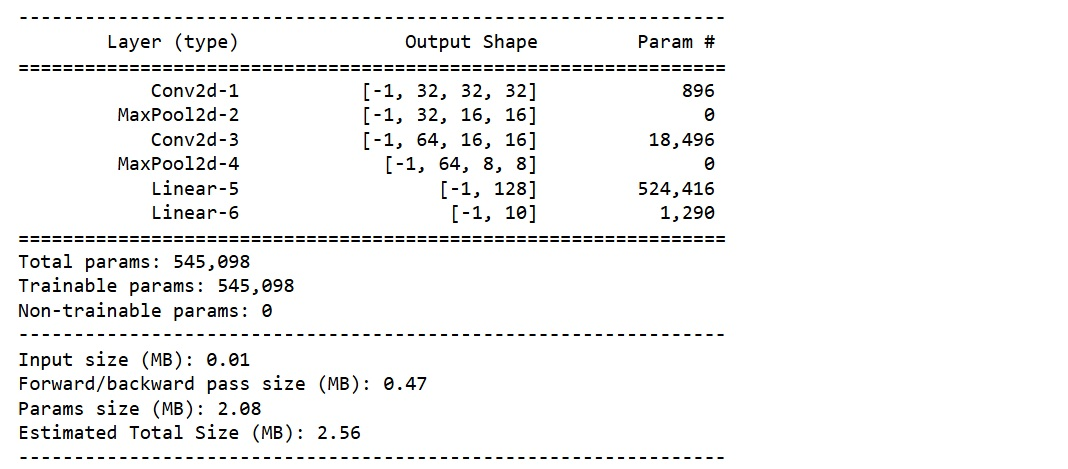

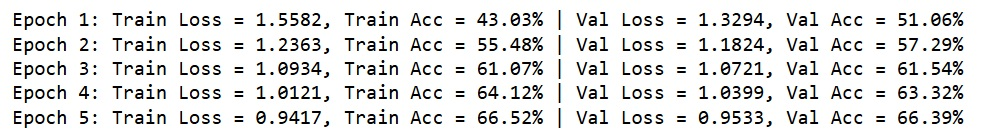

## 3. Experiments and Results

Starting from the baseline model (≈66% validation accuracy), several architectural and training adjustments were explored to improve performance.

- ### Model Architecture
    Two additional convolutional layers were added, enabling the network to capture more complex and higher-level features such as textures and object structures.

- ### Regularization
    Weight decay (L2 regularization, 1e-4) was applied to penalize large weights and reduce overfitting.

- ### Optimization
    - A learning rate scheduler (StepLR) was introduced to progressively reduce the learning rate, improving convergence stability.
    - Batch normalization was added after each convolutional layer to stabilize gradients, reduce internal covariate shift, and accelerate training.

- ### Hyperparameter Tuning
    - Batch size increased from 32 to 64, improving training stability and convergence speed  
    - Number of filters expanded (64 → 128 → 256 → 512), allowing the model to learn more complex patterns  
    - Number of epochs increased to 30 to allow sufficient learning time  

- ### Dropout
    Dropout was tested at different rates (0.5, 0.3, 0.25). Initially, it reduced performance, but after increasing model depth, moderate dropout improved generalization.

- ### Data Augmentation
    Additional augmentation techniques (RandomRotation, GaussianBlur, ColorJitter) were tested but reduced performance. The final model retained only HorizontalFlip and RandomCrop, which provided the best results.

- ### Other Experiments
    Increasing kernel size to 5×5 did not significantly impact performance.

### Conclusion
The most impactful improvements came from increasing model depth, adding batch normalization, and expanding the number of filters. These changes increased validation accuracy from ~66% to the mid-80% range.

## 4. Final Convolutional Neural Network (CNN) Model

### 4.1 Model Architecture
* Input: 3x32x32 (RGB images from CIFAR-10)
* Convolutional Layers:
    * Layer 1: 64 filters, kernel size 3x3, stride 1, padding 1.
    * Layer 2: 128 filters, kernel size 3x3, stride 1, padding 1.
    * Layer 3: 256 filters, kernel size 3x3, stride 1, padding 1.
    * Layer 4: 512 filters, kernel size 3x3, stride 1, padding 1.
* Batch Normalization after each convolutional layer to stabilize training.
* Max Pooling Layers: Max pooling with 2x2 kernel to reduce spatial dimension and improve feature retention.
* Dropout Regularization: 
    * Applied after convolutional layer 2 and 4 (p=0.1).
    * Applied after fully connected layer (p=0.3) to prevent overfitting.
* Fully Connected Layers:
    * Dense 1: 2048 input features, 512 output neurons.
    * Output Layer: 10 neurons, representing the 10 CIFAR-10 classes.
* Activation Function: ReLU for non-linearity in all layers.    
    
### 4.2 Hyperparameters
* Learning Rate: 0.001
* Batch Size: 64
* Epochs: 30

### 4.3 Optimization Techniques
* Data Augmentation: Random flipping, random cropping and normalization.
* Optimizer: Adam (Weight Decay: 1e-4, Learning Rate Scheduler: StepLR).

In [ ]:
# Install packages
!pip install torchsummary
!pip install torchmetrics

In [9]:
# Import libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
import torch.utils as utils
from torch.utils.data import random_split, DataLoader
from torchsummary import summary
import torchmetrics
import torchvision
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [10]:
# Define transformations
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(), # Randomly flips images horizontally 
    transforms.RandomCrop(32, padding=4), # Ramdonly crops image to 32x32 pixels, with 4 pixels padding added before cropping 
    transforms.ToTensor(), # Coverts images to Pytorch tensor, changes pixels values to 0-1
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]) # Normalize each color channel with mean and std, values change to [-1,1]

# Load dataset
training_data = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

Files already downloaded and verified
Files already downloaded and verified


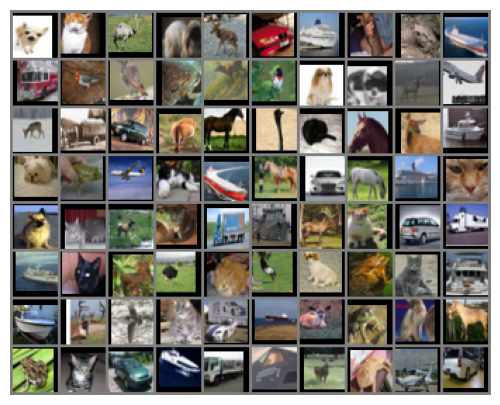

Labels: ['dog', 'cat', 'bird', 'dog', 'deer', 'automobile', 'ship', 'cat', 'frog', 'ship', 'truck', 'bird', 'bird', 'frog', 'deer', 'bird', 'dog', 'cat', 'deer', 'airplane', 'deer', 'truck', 'automobile', 'deer', 'horse', 'bird', 'cat', 'horse', 'deer', 'ship', 'dog', 'frog', 'airplane', 'cat', 'ship', 'horse', 'automobile', 'horse', 'ship', 'cat', 'dog', 'cat', 'deer', 'frog', 'truck', 'ship', 'deer', 'cat', 'automobile', 'truck', 'ship', 'cat', 'deer', 'bird', 'cat', 'bird', 'dog', 'frog', 'cat', 'ship', 'ship', 'deer', 'bird', 'cat', 'automobile', 'ship', 'deer', 'frog', 'cat', 'horse', 'frog', 'cat', 'automobile', 'ship', 'truck', 'airplane', 'deer', 'cat', 'airplane', 'automobile']


In [40]:
# Function to show images
def imshow(img):
    img = img / 2 + 0.5  # Unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    plt.show()

# Get a batch of training data
dataiter = iter(torch.utils.data.DataLoader(training_data, batch_size=80, shuffle=True))
images, labels = next(dataiter)

# Show images
plt.figure(figsize=(10, 5))  
imshow(torchvision.utils.make_grid(images, nrow=10)) 

# Print corresponding labels
print('Labels:', [training_data.classes[label] for label in labels])

In [11]:
# Define split ratios for training and validation 
train_size = int(0.8 * len(training_data))  # 80% of training data
val_size = len(training_data) - train_size  # Remaining 20%

# Perform the random split
train_dataset, val_dataset = random_split(training_data, [train_size, val_size], generator=torch.Generator().manual_seed(64))

# Create DataLoaders for efficient batching 
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Training dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

Training dataset size: 40000
Validation dataset size: 10000
Test dataset size: 10000


In [12]:
# Define CNN Model
class CIFAR10_CNN(nn.Module):
    def __init__(self): 
        super(CIFAR10_CNN, self).__init__() 
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)   
        self.bn1 = nn.BatchNorm2d(64)  
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)  
        self.bn2 = nn.BatchNorm2d(128)  
        self.dropout_conv2 = nn.Dropout2d(p=0.1)  
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1) 
        self.bn3 = nn.BatchNorm2d(256)  
        self.conv4 = nn.Conv2d(256, 512, kernel_size=3, padding=1) 
        self.bn4 = nn.BatchNorm2d(512)  
        self.dropout_conv4 = nn.Dropout2d(p=0.1) 
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout_fc = nn.Dropout(p=0.3)  
        self.fc1 = nn.Linear(512 * 2 * 2, 512)  
        self.bn_fc1 = nn.BatchNorm1d(512)  
        self.fc2 = nn.Linear(512, 10)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.pool(x)       
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)
        x = self.dropout_conv2(x) 
        x = self.relu(self.bn3(self.conv3(x)))
        x = self.pool(x)
        x = self.relu(self.bn4(self.conv4(x)))
        x = self.pool(x)
        x = self.dropout_conv4(x)  
        x = x.view(x.size(0), -1)  
        x = self.relu(self.bn_fc1(self.fc1(x)))
        x = self.dropout_fc(x)  
        x = self.fc2(x)

        return x

In [13]:
# Instantiate model, define the loss function and the optimizer
model = CIFAR10_CNN() # Creates instance of CIFAR10_CNN class
criterion = nn.CrossEntropyLoss() # Defines loss function 
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4) # Adam optimization, learning rate and L2 regularization
scheduler = StepLR(optimizer, step_size=10, gamma=0.1)  # Reduce learning rate every 10 epochs (step size multiplied by gamma)

In [14]:
# Device configuration (CPU/GPU)
# Select device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Move model to device
model.to(device)

# Print model summary
summary(model, input_size=(3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,792
       BatchNorm2d-2           [-1, 64, 32, 32]             128
              ReLU-3           [-1, 64, 32, 32]               0
         MaxPool2d-4           [-1, 64, 16, 16]               0
            Conv2d-5          [-1, 128, 16, 16]          73,856
       BatchNorm2d-6          [-1, 128, 16, 16]             256
              ReLU-7          [-1, 128, 16, 16]               0
         MaxPool2d-8            [-1, 128, 8, 8]               0
         Dropout2d-9            [-1, 128, 8, 8]               0
           Conv2d-10            [-1, 256, 8, 8]         295,168
      BatchNorm2d-11            [-1, 256, 8, 8]             512
             ReLU-12            [-1, 256, 8, 8]               0
        MaxPool2d-13            [-1, 256, 4, 4]               0
           Conv2d-14            [-1, 51

In [15]:
# Train model
num_epochs = 30 # Defines number of epochs (iterations)

train_acc_list = [] # Initializes an empty list to store training accuracy per epoch
val_acc_list = [] # Initializes an empty list to store validation accuracy per epoch

train_loss_list = [] # Initializes an empty list to store training loss per epoch
val_loss_list = []  # Initializes an empty list to store validation loss per epoch

for epoch in range(num_epochs): # Model to train 30 epochs over dataset
    # Training phase
    model.train() # Activares training mode
    running_loss = 0 # Resets tracking variable
    correct, total = 0, 0 # Resets tracking variables

    for data, target in train_loader: # Loops through training data in batches
        data, target = data.to(device), target.to(device) # Move data to same device as model
        
        optimizer.zero_grad() # Zero out out previous gradients
        output = model(data) # Forward pass
        loss = criterion(output, target) # Computes loss, output predictions vs target labels
        loss.backward() # Backward pass and gradient calculation
        optimizer.step() # Updates model weights based on computed gradients
        
        running_loss += loss.item() # Accumulates training total loss for the current epoch
        _, predicted = torch.max(output, 1) # Finds highest scoring class for each image, stores predicted labels 
        total += target.size(0) # Counts processed samples
        correct += (predicted == target).sum().item() # Tracks how many predictions were correct

    train_accuracy = 100 * correct / total # Calculates accuracy
    train_acc_list.append(train_accuracy) # Appends accuracy per epoch 
    avg_train_loss = running_loss / len(train_loader) # Calculates average loss 
    train_loss_list.append(avg_train_loss) # Appends loss per epoch 
    
    # Validation phase
    model.eval() # Activates evaluation mode
    val_loss = 0 # Resets tracking variable
    correct_val, total_val = 0, 0 # Resets tracking variables

    with torch.no_grad():  # Disables gradient updates for validation
        for data, target in val_loader: # Loops through validation data in batches
            data, target = data.to(device), target.to(device)  # Move data to same device as model
            
            output = model(data) # Forward pass
            loss = criterion(output, target) # Computes loss, outputs predictions vs target labels
            
            val_loss += loss.item() # Accumulates validation total loss for the current epoch
            _, predicted = torch.max(output, 1) # Finds highest scoring class for each image, stores predicted labels 
            total_val += target.size(0) # Counts processed samples
            correct_val += (predicted == target).sum().item() # Tracks how many predictions were correct

    val_accuracy = 100 * correct_val / total_val # Calculates validation accuracy
    val_acc_list.append(val_accuracy) # Appends accuracy per epoch
    avg_val_loss = val_loss / len(val_loader) # Calculates average loss 
    val_loss_list.append(avg_val_loss) # Appends loss per epoch 
   
    scheduler.step() # Adjust Learning Rate using StepLR 
    
    # Print Metrics
    print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Train Acc = {train_accuracy:.2f}% | Val Loss = {avg_val_loss:.4f}, Val Acc = {val_accuracy:.2f}%")

Epoch 1: Train Loss = 1.3756, Train Acc = 49.83% | Val Loss = 1.1031, Val Acc = 60.32%
Epoch 2: Train Loss = 0.9966, Train Acc = 64.65% | Val Loss = 0.9214, Val Acc = 66.82%
Epoch 3: Train Loss = 0.8605, Train Acc = 69.56% | Val Loss = 0.7886, Val Acc = 72.46%
Epoch 4: Train Loss = 0.7840, Train Acc = 72.67% | Val Loss = 0.7265, Val Acc = 74.53%
Epoch 5: Train Loss = 0.7277, Train Acc = 74.60% | Val Loss = 0.7235, Val Acc = 75.11%
Epoch 6: Train Loss = 0.6775, Train Acc = 76.53% | Val Loss = 0.6684, Val Acc = 76.84%
Epoch 7: Train Loss = 0.6405, Train Acc = 77.50% | Val Loss = 0.6060, Val Acc = 79.05%
Epoch 8: Train Loss = 0.6133, Train Acc = 78.82% | Val Loss = 0.6116, Val Acc = 79.05%
Epoch 9: Train Loss = 0.5866, Train Acc = 79.68% | Val Loss = 0.5881, Val Acc = 79.32%
Epoch 10: Train Loss = 0.5696, Train Acc = 80.22% | Val Loss = 0.6004, Val Acc = 78.97%
Epoch 11: Train Loss = 0.4585, Train Acc = 84.22% | Val Loss = 0.4648, Val Acc = 84.13%
Epoch 12: Train Loss = 0.4240, Train Acc 

### 4.4 Model Evaluation

The final model achieves:
- Training accuracy: 89.53%  
- Validation accuracy: 86.70%  
- Test accuracy: 86.39%  

The training and validation accuracy curves show a clear learning phase during the first 10 epochs, where both metrics increase steadily. A noticeable dip occurs around epoch 10, which likely corresponds to the learning rate reduction introduced by the scheduler. After this point, the model stabilizes and continues improving without significant divergence between training and validation performance.

The close alignment between training and validation accuracy indicates limited overfitting and good generalization. Toward the final epochs, both curves plateau, suggesting that the model has reached its learning capacity and additional epochs would yield minimal improvement.

The loss curves follow the expected inverse relationship with accuracy, decreasing as the model improves its predictions.

Overall, the test accuracy (86.39%) confirms that the model generalizes well to unseen data, especially considering the complexity of the CIFAR-10 dataset.

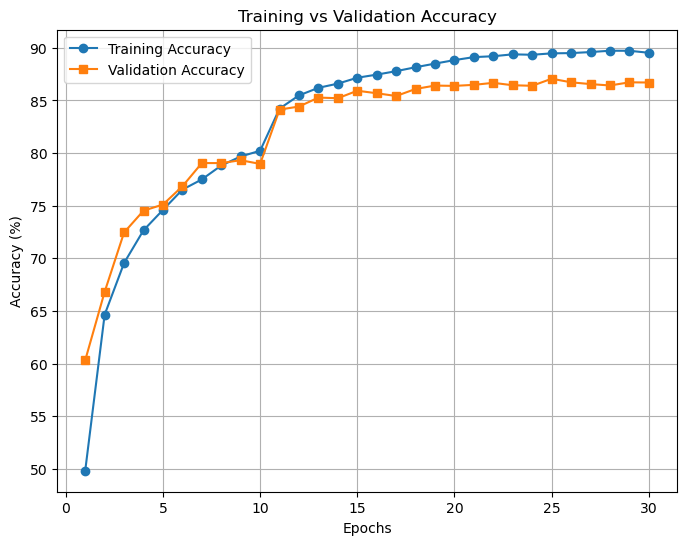

In [17]:
# Plot Training vs Validation Accuracy
plt.figure(figsize=(8, 6))
plt.plot(range(1, num_epochs+1), train_acc_list, label="Training Accuracy", marker='o')
plt.plot(range(1, num_epochs+1), val_acc_list, label="Validation Accuracy", marker='s')
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid()
plt.show()

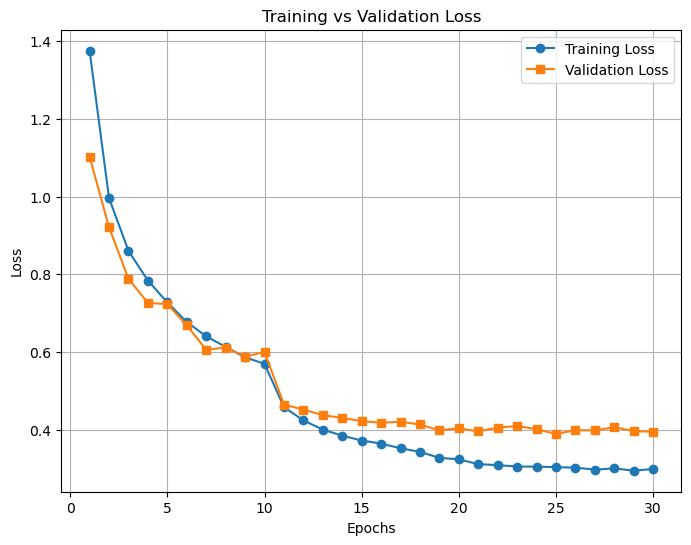

In [16]:
# Plot Training vs Validation Loss
plt.figure(figsize=(8, 6))
plt.plot(range(1, num_epochs+1), train_loss_list, label="Training Loss", marker='o')
plt.plot(range(1, num_epochs+1), val_loss_list, label="Validation Loss", marker='s')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid()
plt.show()

In [18]:
# Calculate Test Accuracy
correct, total = 0, 0 # Resets tracking variables

model.eval()  # Set model to evaluation mode
with torch.no_grad():  # Disable gradient tracking for efficiency
    for data, target in test_loader:  # Iterate over test batches
        output = model(data)  # Forward pass
        _, predicted = torch.max(output, 1)  # Get predicted class labels
        total += target.size(0)  # Count total test samples
        correct += (predicted == target).sum().item()  # Count correct predictions

test_accuracy = 100 * correct / total # Calculate test accuracy

# Print Metric
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 86.39%


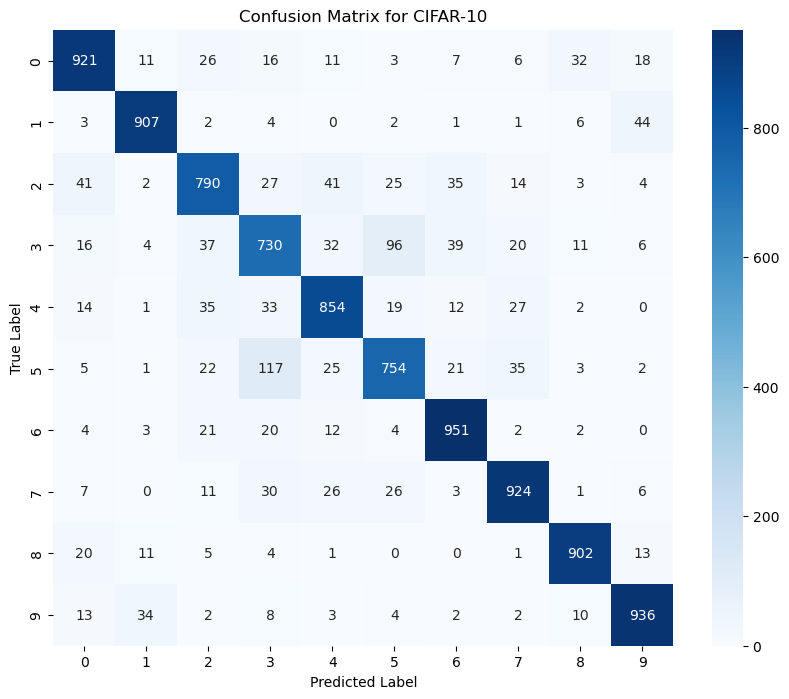

In [21]:
# Calculate true and predicted labels
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # Checks if GPU is available, defaults to CPU

true_labels = [] # Initialize list to track true labels
pred_labels = [] # Initialize list to track predicted labels

model.eval()  # Set to evaluation mode
with torch.no_grad(): # Disables gradient tracking
    for images, labels in val_loader: # Loops through validation dataset
        images, labels = images.to(device), labels.to(device) # Moves images and labels to device
        outputs = model(images) # Forward pass
        _, preds = torch.max(outputs, 1) # Finds highest probability class
        true_labels.extend(labels.cpu().numpy()) # Converts tensors to NumPy arrays and stores values in list
        pred_labels.extend(preds.cpu().numpy()) # Converts tensors to NumPy arrays and stores values in list

# Compute confusion matrix
conf_matrix = confusion_matrix(true_labels, pred_labels)

# Plot confusion matrix
plt.figure(figsize=(10,8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=range(10), yticklabels=range(10))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for CIFAR-10")
plt.show()

### Confusion Matrix Analysis

For reference, the class labels are mapped as follows:
0: airplane, 1: automobile, 2: bird, 3: cat, 4: deer, 5: dog, 6: frog, 7: horse, 8: ship, 9: truck.

The most significant misclassification occurs between the "Dog" and "Cat" classes. Specifically, 117 images labeled as Dog were predicted as Cat, and 96 images labeled as Cat were predicted as Dog. This confusion is expected, as both classes share similar visual features such as shape, texture, and pose, making them difficult to distinguish—especially at low resolution.

The model also shows weaker performance on the "Bird" class. Bird images were frequently misclassified as Airplane (41), Deer (41), Frog (35), Cat (27), and Dog (25). This suggests that the model struggles to capture distinguishing features for birds, likely due to the low resolution and high variability in appearance. In some cases, birds may appear as small or indistinct shapes, leading to confusion with other classes that share similar outlines or backgrounds.

These patterns indicate that the model has difficulty capturing fine-grained features and differentiating between visually similar classes. This is a common challenge in CIFAR-10 due to the complexity of natural images.

### 5. Future Improvements

While the final model achieves strong performance (~86% test accuracy), several improvements could further enhance results.

Performance could be further improved by adopting a ResNet-style architecture, which uses residual connections to enable deeper and more effective training. 

Additional gains may be achieved through improved data augmentation, more advanced learning rate scheduling, and longer training with early stopping. These changes would help the model capture more complex features and improve generalization.